In [1]:
import os
from glob import glob

import pandas as pd
import numpy as np

import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

# %matplotlib ipympl
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [15, 4]


In [2]:
def replace_str(logs_dir, a, b):
    csv_file_paths = glob(os.path.join(logs_dir, "*.csv"))
    dfs = list()
    for csv_file_path in csv_file_paths:
        lines = list()
        replace_lines = list()
        with open(csv_file_path, 'r') as f:
            lines = f.readlines()
        
        with open(csv_file_path, 'w') as f:
            for s in lines:
                print(s)
                r = s.replace(a, b)
                print(r)
                f.write(r)

# replace_str(logs_dir=os.path.expanduser("~/asb_logs/performance_measurements/original/"), a="updateBounds", b="update_bounds")
# replace_str(logs_dir=os.path.expanduser("~/asb_logs/performance_measurements/current/"), a="updateBounds", b="update_bounds")

In [3]:
def load_measurements(logs_dir):
    csv_file_paths = glob(os.path.join(logs_dir, "*.csv"))
    dfs = list()
    for csv_file_path in sorted(csv_file_paths):
        d = pd.read_csv(os.path.expanduser(csv_file_path), header=[0, 1, 2])
        d[('filename', '', '')] = os.path.basename(csv_file_path)
        dfs.append(d)
    return pd.concat(dfs, ignore_index=True)

def load_data():
    global df_o
    global df_c
    global df
    
    # df_o = load_measurements(os.path.expanduser("~/asb_logs/performance_measurements/original/"))
    df_o = load_measurements(os.path.expanduser("~/asb_logs/performance_measurements/early_stop_raytracing/"))
    df_c = load_measurements(os.path.expanduser("~/asb_logs/performance_measurements/current"))
    
    df = pd.concat(dict(original=df_o, current=df_c), axis=1)
    df = df.reorder_levels([1, 2, 3, 0], axis=1)

def plot_hist_local_costmap_execution_duration(metric):
    df_execution_duration_ms = df.execution_duration * 1000  # [ms]
    df_update_bounds = df_execution_duration_ms[('local_costmap.update_bounds', metric)]  # [ms]
    df_raytracing = df_execution_duration_ms[('local_costmap.raytracing', metric)]  # [ms]
    
    print(f"{metric}:")
    print(f"    update_bounds")
    print(f"        original: {df_update_bounds.mean().original:.3f}")
    print(f"        current:  {df_update_bounds.mean().current:.3f}")
    print(f"        delta:    {df_update_bounds.mean().current - df_update_bounds.mean().original:+.3f}")
    print(f"    raytracing")
    print(f"        original: {df_raytracing.mean().original:.3f}")
    print(f"        current:  {df_raytracing.mean().current:.3f}")
    print(f"        delta:    {df_raytracing.mean().current - df_raytracing.mean().original:+.3f}")
    
    max_h = df_execution_duration_ms['local_costmap.update_bounds'].max().max()
    bins = np.arange(0, max_h+2, 1.0)  # 1 ms bin width
    
    fig, axs = plt.subplots(nrows=2, ncols=1)
    
    axs[0].hist(df_update_bounds.original, bins, density=True, histtype='barstacked', rwidth=0.9, facecolor='g')
    axs[0].hist(df_update_bounds.current, bins, density=True, histtype='step', color='blue', linewidth=3)
    axs[0].set_title('update_bounds')
    
    axs[1].hist(df_raytracing.original, bins, density=True, histtype='barstacked', rwidth=0.9, facecolor='g')
    axs[1].hist(df_raytracing.current, bins, density=True, histtype='step', color='blue', linewidth=3)
    axs[1].set_title('raytracing')
    
    axs[1].set_xlabel(f'{metric} [ms]')
    
    fig.tight_layout()
    plt.show()

def plot_hist_controller_server_cpu_usage():
    df_cpu_usage = df[('cpu_usage', 'controller_server', 'average_cpu_usage')] * 100  # [%]
    
    print(f"cpu_usage:")
    print(f"     original: {df_cpu_usage.mean().original:.3f}")
    print(f"     current:  {df_cpu_usage.mean().current:.3f}")
    print(f"     delta:    {df_cpu_usage.mean().current - df_cpu_usage.mean().original:+.3f}")
    
    max_h = df_cpu_usage.max().max()
    bins = np.arange(0, max_h+2, 1.0)  # 1 [%] bin width
    
    fig, ax = plt.subplots()
    ax.hist(df_cpu_usage.original, bins, density=True, histtype='barstacked', rwidth=0.9, facecolor='g')
    ax.hist(df_cpu_usage.current, bins, density=True, histtype='step', color='blue', linewidth=3)
    ax.set_title('controller_server')
    ax.set_xlabel('average_cpu_usage [%]')
    
    fig.tight_layout()
    plt.show()

min_execution_duration:
    update_bounds
        original: 15.235
        current:  12.182
        delta:    -3.052
    raytracing
        original: 13.607
        current:  10.270
        delta:    -3.337


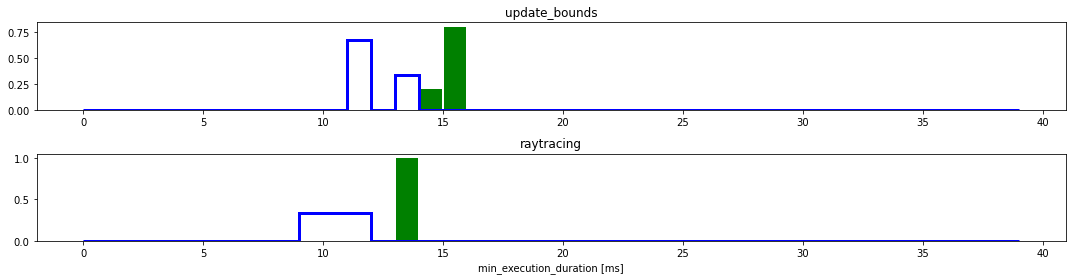

average_execution_duration:
    update_bounds
        original: 28.768
        current:  20.702
        delta:    -8.066
    raytracing
        original: 25.841
        current:  17.578
        delta:    -8.263


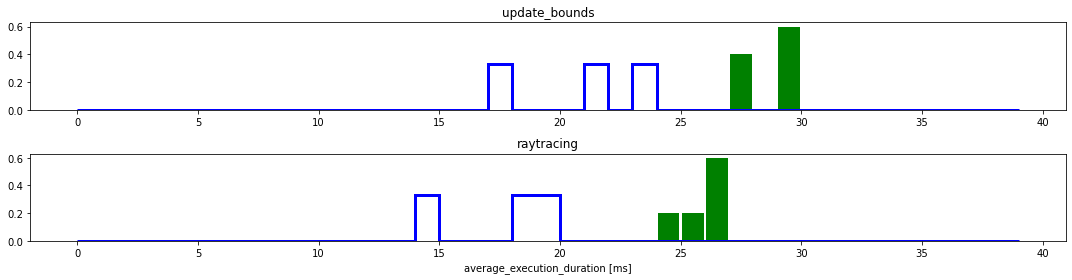

max_execution_duration:
    update_bounds
        original: 35.741
        current:  29.056
        delta:    -6.685
    raytracing
        original: 32.601
        current:  24.566
        delta:    -8.035


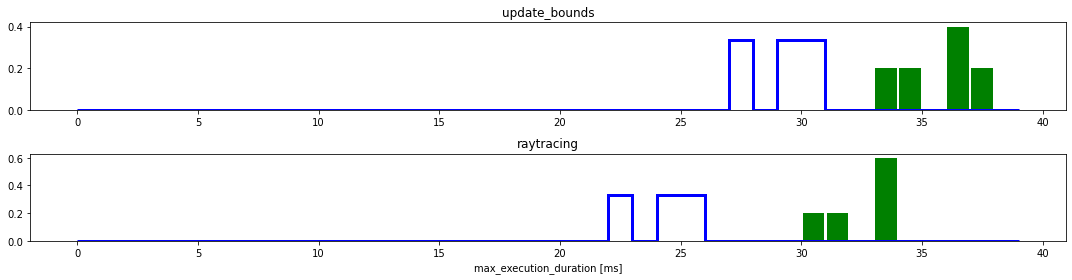

cpu_usage:
     original: 44.741
     current:  35.519
     delta:    -9.222


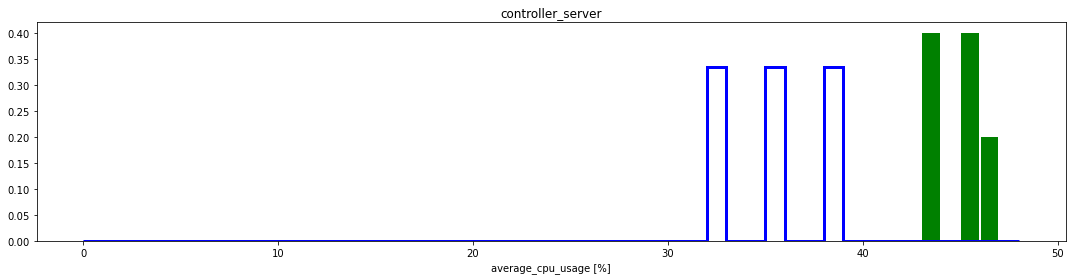

In [4]:
load_data()
plot_hist_local_costmap_execution_duration(metric='min_execution_duration')
plot_hist_local_costmap_execution_duration(metric='average_execution_duration')
plot_hist_local_costmap_execution_duration(metric='max_execution_duration')
plot_hist_controller_server_cpu_usage()